# Spectral Geometry of Linear Regression

Before analyzing linear regression carefully, it helps to see the geometry hidden inside $X^T X$.


## The canonical decomposition of $X^T X$

For any real design matrix $X$, the matrix

$$A = X^T X$$

is symmetric and positive semidefinite. By the spectral theorem, it has an orthogonal eigendecomposition

$$X^T X = Q \Lambda Q^T,$$

often remembered informally as a rotation-reflection matrix $Q$, a diagonal scaling matrix $\Lambda$, and the inverse rotation $Q^T$. In this demo we write the diagonal matrix as $L$.

The pieces have precise roles:

- $Q$ is orthogonal: $Q^TQ = QQ^T = I$. Its columns are perpendicular unit eigenvectors.
- $L = \operatorname{diag}(\lambda_1, \lambda_2)$ contains the eigenvalues of $X^T X$.
- Because $X^T X$ is positive semidefinite, every eigenvalue is nonnegative.
- The quadratic landscape $w^T X^T Xw$ is flat in directions with small eigenvalues and steep in directions with large eigenvalues.
- If an eigenvalue is zero or very close to zero, the inverse or pseudo-inverse can strongly amplify even small noise.


In [1]:
import json
from pathlib import Path

import numpy as np
import json_tricks


def is_obfuscated():
    return '__pyarmor__' in globals()


try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError:
    widgets = None

try:
    if is_obfuscated():
        raise ImportError
    import ipympl  # enables the %matplotlib widget backend
    get_ipython().run_line_magic('matplotlib', 'widget')
    MATPLOTLIB_WIDGET_READY = True
except (ImportError, NameError):
    MATPLOTLIB_WIDGET_READY = False

import matplotlib
if is_obfuscated():
    matplotlib.use('Agg')
import matplotlib.pyplot as plt

answer = {}


## Build $Q$, build $L$, and watch the landscape

The angle control rotates the first eigenvector of the two-dimensional $Q$ matrix. The eigenvalue controls set $\lambda_1$ and $\lambda_2$ directly, so smaller values make that direction flatter and more noise-sensitive. Together they create

$$X^T X = QLQ^T.$$

The interactive contour plot shows levels of $w^T X^T Xw$. The solid colored arrows are unit eigenvectors, and the dashed colored axes have length $1 / \sqrt{\lambda_i}$. The orange path shows 20 gradient descent steps on the same quadratic. The pink points show pseudo-inverse solutions to

$$Xw = \varepsilon, \qquad w = (X^T X)^+X^T\varepsilon,$$

where $\varepsilon$ is random noise. The demo uses one different $\varepsilon$ vector for each gradient descent step. When an eigenvalue is small, those errors can become surprisingly large weights.

Use the controls to look for the eigenvalues that make gradient descent converge as fast as possible. The relevant warning light is the condition number

$$\kappa = \frac{\max(\lambda_1, \lambda_2)}{\min(\lambda_1, \lambda_2)}.$$


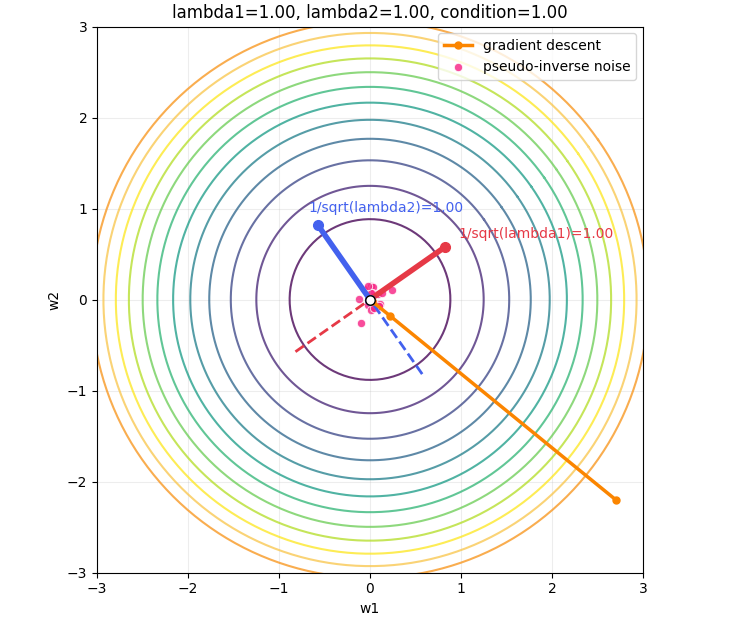

In [2]:
GRADIENT_STEPS = 20
MIN_EIGENVALUE = 0.1
MAX_EIGENVALUE = 10.0
BASE_EXTENT = 3.0
CONTOUR_LEVELS = 12
CONTOUR_POINTS = 181
CONTOUR_COLORS = [
    '#440154', '#482878', '#3e4989', '#31688e', '#26828e', '#1f9e89',
    '#35b779', '#6ece58', '#b5de2b', '#fde725', '#f9c74f', '#f8961e',
]

rng = np.random.default_rng(42)
noise_samples = rng.normal(scale=0.12, size=(GRADIENT_STEPS, 2))
contour_angles = np.linspace(0.0, 2.0 * np.pi, CONTOUR_POINTS)

SPECTRAL_WIDGET_STATE_PATH = Path('.spectral_widget_state.json')
DEFAULT_SPECTRAL_WIDGET_STATE = {
    'angle_degrees': 35.0,
    'lambda_1': 1.0,
    'lambda_2': 1.0,
}


def clipped_float(value, minimum, maximum):
    return min(maximum, max(minimum, float(value)))


def load_spectral_widget_state():
    state = DEFAULT_SPECTRAL_WIDGET_STATE.copy()
    if SPECTRAL_WIDGET_STATE_PATH.exists():
        try:
            saved_state = json.loads(SPECTRAL_WIDGET_STATE_PATH.read_text())
            state.update(saved_state)
        except (OSError, TypeError, ValueError):
            pass
    state['angle_degrees'] = clipped_float(state['angle_degrees'], 0.0, 360.0)
    state['lambda_1'] = clipped_float(state['lambda_1'], MIN_EIGENVALUE, MAX_EIGENVALUE)
    state['lambda_2'] = clipped_float(state['lambda_2'], MIN_EIGENVALUE, MAX_EIGENVALUE)
    return state


def save_spectral_widget_state(angle_degrees, lambda_1, lambda_2):
    state = {
        'angle_degrees': float(angle_degrees),
        'lambda_1': float(lambda_1),
        'lambda_2': float(lambda_2),
    }
    SPECTRAL_WIDGET_STATE_PATH.write_text(json.dumps(state, indent=2))



def make_q(angle_degrees):
    theta = np.deg2rad(angle_degrees)
    first = np.array([np.cos(theta), np.sin(theta)])
    second = np.array([-np.sin(theta), np.cos(theta)])
    return np.column_stack([first, second])


def make_xtx(angle_degrees, lambda_1, lambda_2):
    Q = make_q(angle_degrees)
    L = np.diag([lambda_1, lambda_2])
    return Q @ L @ Q.T, Q, L


def positive_eigenvalue(eigenvalue):
    return max(float(eigenvalue), MIN_EIGENVALUE)


def condition_number_from_lambdas(lambda_1, lambda_2):
    lambda_1 = positive_eigenvalue(lambda_1)
    lambda_2 = positive_eigenvalue(lambda_2)
    return max(lambda_1, lambda_2) / min(lambda_1, lambda_2)


def gradient_descent_path(A, steps=GRADIENT_STEPS):
    w = np.array([2.7, -2.2], dtype=float)
    largest_eigenvalue = max(float(np.linalg.eigvalsh(A).max()), 1e-8)
    learning_rate = 0.92 / (2.0 * largest_eigenvalue)
    path = [w.copy()]
    for _ in range(steps):
        w = w - learning_rate * (2.0 * A @ w)
        path.append(w.copy())
    return np.array(path)


def pseudo_inverse_noise_points(Q, L):
    X = np.sqrt(L) @ Q.T
    return np.array([np.linalg.pinv(X) @ eps for eps in noise_samples])


def contour_points(Q, lambda_1, lambda_2, visible_extent):
    max_level = 0.52 * visible_extent ** 2 * (lambda_1 + lambda_2)
    levels = np.linspace(max_level / CONTOUR_LEVELS, max_level, CONTOUR_LEVELS)
    cos_t = np.cos(contour_angles)
    sin_t = np.sin(contour_angles)
    curves = []
    for level in levels:
        eigen_coordinates = np.vstack([
            np.sqrt(level / lambda_1) * cos_t,
            np.sqrt(level / lambda_2) * sin_t,
        ])
        curves.append(Q @ eigen_coordinates)
    return curves


def landscape_state(angle_degrees=35, lambda_1=6.0, lambda_2=0.7):
    lambda_1 = positive_eigenvalue(lambda_1)
    lambda_2 = positive_eigenvalue(lambda_2)
    reciprocals = np.array([1.0 / np.sqrt(lambda_1), 1.0 / np.sqrt(lambda_2)])
    A, Q, L = make_xtx(angle_degrees, lambda_1, lambda_2)
    path = gradient_descent_path(A)
    noise_points = pseudo_inverse_noise_points(Q, L)
    visible_extent = max(
        BASE_EXTENT,
        1.18 * float(reciprocals.max()),
        1.08 * float(np.abs(path).max()),
        1.08 * float(np.abs(noise_points).max()),
    )
    curves = contour_points(Q, lambda_1, lambda_2, visible_extent)
    condition = condition_number_from_lambdas(lambda_1, lambda_2)
    title = f'lambda1={lambda_1:.2f}, lambda2={lambda_2:.2f}, condition={condition:.2f}'
    return Q, np.diag(L), reciprocals, path, noise_points, visible_extent, curves, title


def make_stepper(label, value, step, minimum, maximum, width='96px'):
    minus = widgets.Button(description='-', layout=widgets.Layout(width='34px'))
    plus = widgets.Button(description='+', layout=widgets.Layout(width='34px'))
    field = widgets.BoundedFloatText(
        value=value,
        min=minimum,
        max=maximum,
        step=step,
        description=label,
        layout=widgets.Layout(width=width),
        style={'description_width': 'initial'},
    )

    def nudge(delta):
        def handler(_):
            field.value = min(maximum, max(minimum, field.value + delta))
        return handler

    minus.on_click(nudge(-step))
    plus.on_click(nudge(step))
    return widgets.HBox([minus, field, plus]), field


def build_spectral_landscape():
    if is_obfuscated():
        return None
    if widgets is None:
        print('Install ipywidgets to use the live controls.')
        return None
    if not MATPLOTLIB_WIDGET_READY:
        print('Install ipympl to use the fast live matplotlib widget: pip install ipympl')
        return None

    saved_state = load_spectral_widget_state()
    angle_control, angle_field = make_stepper('angle', saved_state['angle_degrees'], 5.0, 0.0, 360.0, width='118px')
    lambda_1_control, lambda_1_field = make_stepper('lambda 1', saved_state['lambda_1'], 0.1, MIN_EIGENVALUE, MAX_EIGENVALUE, width='128px')
    lambda_2_control, lambda_2_field = make_stepper('lambda 2', saved_state['lambda_2'], 0.1, MIN_EIGENVALUE, MAX_EIGENVALUE, width='128px')

    fig, ax = plt.subplots(figsize=(7.4, 6.2), constrained_layout=True)
    contour_lines = [ax.plot([], [], color=color, linewidth=1.5, alpha=0.78)[0] for color in CONTOUR_COLORS]
    reciprocal_axis_lines = [ax.plot([], [], linestyle='--', linewidth=2.0)[0] for _ in range(2)]
    unit_vector_lines = [ax.plot([], [], marker='o', linewidth=4.0, markersize=7)[0] for _ in range(2)]
    path_line = ax.plot([], [], color='#fb8500', marker='o', linewidth=2.5, markersize=5, label='gradient descent')[0]
    noise_artist = ax.scatter([], [], s=36, color='#f72585', edgecolor='white', linewidth=0.7, alpha=0.82, label='pseudo-inverse noise')
    origin_artist = ax.scatter([0], [0], s=46, color='white', edgecolor='black', linewidth=1.0, zorder=5)
    annotations = [ax.text(0, 0, '', fontsize=10) for _ in range(2)]

    for line, color in zip(reciprocal_axis_lines, ['#e63946', '#4361ee']):
        line.set_color(color)
    for line, color in zip(unit_vector_lines, ['#e63946', '#4361ee']):
        line.set_color(color)
        line.set_markerfacecolor(color)
        line.set_markeredgecolor(color)

    ax.set_xlabel('w1')
    ax.set_ylabel('w2')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.22)
    ax.legend(loc='upper right')

    def update(_=None):
        global chosen_lambda_1, chosen_lambda_2, spectral_widget_lambdas
        chosen_lambda_1 = float(lambda_1_field.value)
        chosen_lambda_2 = float(lambda_2_field.value)
        spectral_widget_lambdas = (chosen_lambda_1, chosen_lambda_2)
        save_spectral_widget_state(angle_field.value, chosen_lambda_1, chosen_lambda_2)
        Q, eigenvalues, reciprocals, path, noise_points, visible_extent, curves, title = landscape_state(
            angle_field.value,
            chosen_lambda_1,
            chosen_lambda_2,
        )
        for line, curve in zip(contour_lines, curves):
            line.set_data(curve[0], curve[1])
        for index, line in enumerate(reciprocal_axis_lines):
            vector = Q[:, index] * reciprocals[index]
            line.set_data([-vector[0], vector[0]], [-vector[1], vector[1]])
            line.set_label(f'1/sqrt(lambda) axis {index + 1}: {reciprocals[index]:.2f}')
        for index, line in enumerate(unit_vector_lines):
            direction = Q[:, index]
            line.set_data([0.0, direction[0]], [0.0, direction[1]])
            line.set_label(f'unit q{index + 1}, lambda={eigenvalues[index]:.2f}')
            label_point = direction * (reciprocals[index] + 0.18)
            annotations[index].set_position(label_point)
            annotations[index].set_text(f'1/sqrt(lambda{index + 1})={reciprocals[index]:.2f}')
            annotations[index].set_color(line.get_color())
        path_line.set_data(path[:, 0], path[:, 1])
        noise_artist.set_offsets(noise_points)
        origin_artist.set_offsets(np.array([[0.0, 0.0]]))
        ax.set_xlim(-visible_extent, visible_extent)
        ax.set_ylim(-visible_extent, visible_extent)
        ax.set_title(title)
        fig.canvas.draw_idle()

    for field in (angle_field, lambda_1_field, lambda_2_field):
        field.observe(update, names='value')

    controls = widgets.HBox([angle_control, lambda_1_control, lambda_2_control])
    display(controls)
    update()
    return fig, ax


live_landscape = build_spectral_landscape()


## Task: make gradient descent as fast as possible

For a two-dimensional quadratic loss with Hessian geometry controlled by eigenvalues $\lambda_1$ and $\lambda_2$, gradient descent converges fastest when the landscape is as round as possible. In this task, choose eigenvalues in the interval $[0.1, 10]$ that make gradient descent as fast as possible. For the found eigenvalues, compute the condition number:

$\kappa = \frac{\lambda_{max}}{\lambda_{min}}$

Set `chosen_lambda_1` and `chosen_lambda_2`, compute the condition number, and store only that condition number in `answer['condition_number']`.


In [3]:
if 'spectral_widget_lambdas' in globals():
    chosen_lambda_1, chosen_lambda_2 = spectral_widget_lambdas
else:
    saved_state = load_spectral_widget_state()
    chosen_lambda_1 = saved_state['lambda_1']
    chosen_lambda_2 = saved_state['lambda_2']

## YOUR CODE HERE

condition_number = condition_number_from_lambdas(chosen_lambda_1, chosen_lambda_2)
answer['condition_number'] = condition_number

print('chosen lambda 1:', chosen_lambda_1)
print('chosen lambda 2:', chosen_lambda_2)
print('condition number:', condition_number)


chosen lambda 1: 1.0
chosen lambda 2: 1.0
condition number: 1.0


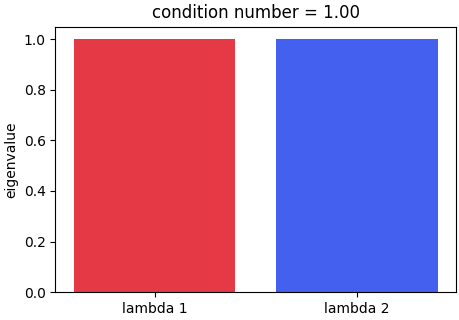

In [4]:
np.testing.assert_array_less(0, chosen_lambda_1)
np.testing.assert_array_less(0, chosen_lambda_2)
np.testing.assert_array_less(0.0, answer['condition_number'])

fig, ax = plt.subplots(figsize=(4.6, 3.2), constrained_layout=True)
ax.bar(['lambda 1', 'lambda 2'], [chosen_lambda_1, chosen_lambda_2], color=['#e63946', '#4361ee'])
ax.set_ylabel('eigenvalue')
ax.set_title(f'condition number = {answer["condition_number"]:.2f}')
plt.show()


In [5]:
json_tricks.dump(answer, '.answer.json')


'{"condition_number": 1.0}'

## Conclusion

The eigenvalues of $X^T X$ control the practical difficulty of linear regression. Large differences between eigenvalues make the loss landscape long and narrow, so gradient descent may move slowly or awkwardly unless the step size is chosen with care. Very small eigenvalues also make the pseudo-inverse unstable: tiny noise in $Xw = \varepsilon$ can be amplified into large changes in $w$.

So both optimization and closed-form solving depend on the same geometry. Gradient descent does not always work well, and even the pseudo-inverse is not always stable; the eigenvalues of $X^T X$ are the warning lights.
